# Task 6: House Price Prediction

**Intern:** Hafsa Atif
**Internship:** DevelopersHub Corporation — AI/ML Engineering Internship

**Objective:** Predict house sale prices from property features (living
area, quality rating, year built, etc.) using the Kaggle "House Prices:
Advanced Regression Techniques" dataset. Dataset loads directly from a
public URL — no Kaggle download needed.

### Import Libraries

In [1]:
# pandas/numpy for data handling
import pandas as pd
import numpy as np
# matplotlib/seaborn for charts
import matplotlib.pyplot as plt
import seaborn as sns

# train/test split utility
from sklearn.model_selection import train_test_split
# Gradient Boosting — tree-based regressor, usually stronger than plain Linear Regression
from sklearn.ensemble import GradientBoostingRegressor
# regression evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


### Load the Dataset

In [2]:
# direct CSV URL for the official Kaggle train.csv (Ames, Iowa housing data)
url = 'http://d2l-data.s3-accelerate.amazonaws.com/kaggle_house_pred_train.csv'

# pandas can read a CSV straight from a URL
df = pd.read_csv(url)

# confirm shape: should be 1460 rows, 81 columns
print('Shape:', df.shape)
# peek at a few columns of interest
df[['LotArea', 'BedroomAbvGr', 'Neighborhood', 'SalePrice']].head(10)

Shape: (1460, 81)


,LotArea,BedroomAbvGr,Neighborhood,SalePrice
0,8450,3,CollgCr,208500
1,9600,3,Veenker,181500
2,11250,3,CollgCr,223500
3,9550,3,Crawfor,140000
4,14260,4,NoRidge,250000
5,14115,1,Mitchel,143000
6,10084,3,Somerst,307000
7,10382,3,NWAmes,200000
8,6120,2,OldTown,129900
9,7420,2,BrkSide,118000


### Select Features & Handle Missing Values

In [3]:
# pick a small set of strong, easy-to-explain numeric predictors
features = ['GrLivArea', 'BedroomAbvGr', 'FullBath', 'YearBuilt',
            'OverallQual', 'GarageCars', 'TotalBsmtSF']
target = 'SalePrice'

# build a smaller dataframe with only the columns we need
df_model = df[features + [target]].copy()

# fill any missing numeric values with the column median
df_model.fillna(df_model.median(numeric_only=True), inplace=True)

# confirm no missing values remain
print('Remaining missing values:', df_model.isnull().sum().sum())
df_model.head()

Remaining missing values: 0


,GrLivArea,BedroomAbvGr,FullBath,YearBuilt,OverallQual,GarageCars,TotalBsmtSF,SalePrice
0,1710,3,2,2003,7,2,856,208500
1,1262,3,2,1976,6,2,1262,181500
2,1786,3,2,2001,7,2,920,223500
3,1717,3,1,1915,7,3,756,140000
4,2198,4,2,2000,8,3,1145,250000


### Sale Price Distribution

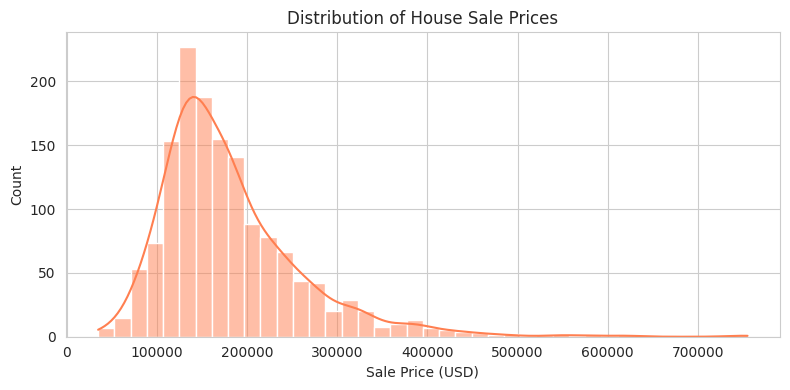

In [4]:
plt.figure(figsize=(8, 4))

# histogram of sale prices with a smooth density curve on top
sns.histplot(df_model['SalePrice'], bins=40, kde=True, color='coral')

plt.title('Distribution of House Sale Prices')
plt.xlabel('Sale Price (USD)')
plt.tight_layout()
plt.show()

### Living Area vs Sale Price

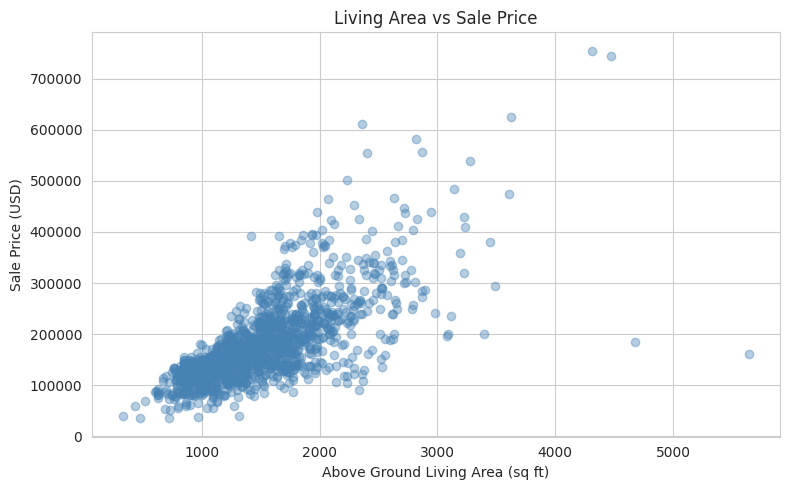

In [5]:
plt.figure(figsize=(8, 5))

# scatter plot: living area (x) vs sale price (y)
plt.scatter(df_model['GrLivArea'], df_model['SalePrice'], alpha=0.4, color='steelblue')

plt.xlabel('Above Ground Living Area (sq ft)')
plt.ylabel('Sale Price (USD)')
plt.title('Living Area vs Sale Price')
plt.tight_layout()
plt.show()

### Train-Test Split & Train the Model

In [6]:
# X = the 7 chosen features, y = the price we want to predict
X = df_model[features]
y = df_model[target]

# 80% training data, 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42   # random_state makes this reproducible
)

# Gradient Boosting: builds many small trees, each correcting the last one's errors
model = GradientBoostingRegressor(
    n_estimators=200,     # number of trees to build
    learning_rate=0.1,    # how much each tree corrects the previous error
    max_depth=4,          # how deep each individual tree can grow
    random_state=42
)
# fit the model on the training data
model.fit(X_train, y_train)

# predict prices for the test set
y_pred = model.predict(X_test)
print('Model trained!')

Model trained!


### Evaluate the Model

In [7]:
# average absolute difference between actual and predicted price
mae = mean_absolute_error(y_test, y_pred)
# root mean squared error — penalizes big mistakes more heavily than MAE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# R2 — how much of the price variation the model explains (1.0 = perfect)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error: ${mae:,.0f}')
print(f'Root Mean Sq Error: ${rmse:,.0f}')
print(f'R2 Score: {r2:.4f}')

Mean Absolute Error: $19,139
Root Mean Sq Error: $28,810
R2 Score: 0.8918


### Actual vs Predicted Prices

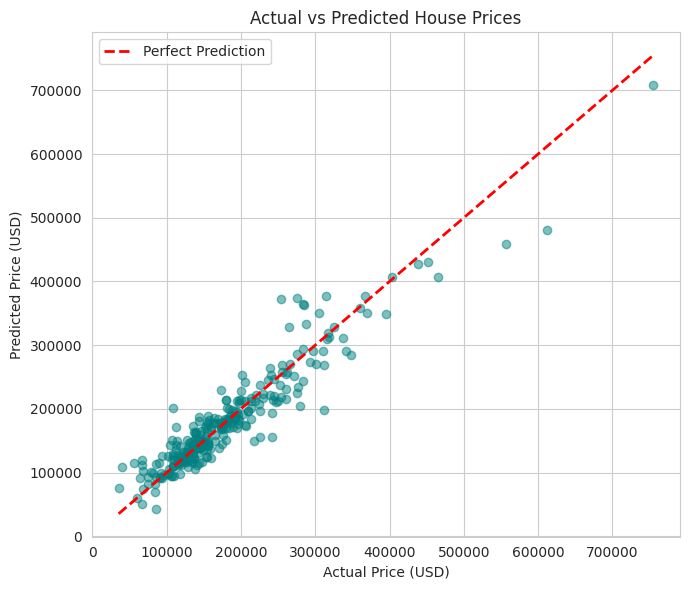

In [8]:
plt.figure(figsize=(7, 6))

# each point = one house: x = actual price, y = predicted price
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')

# diagonal red line = where actual would equal predicted (perfect prediction)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.tight_layout()
plt.show()

### Feature Importance

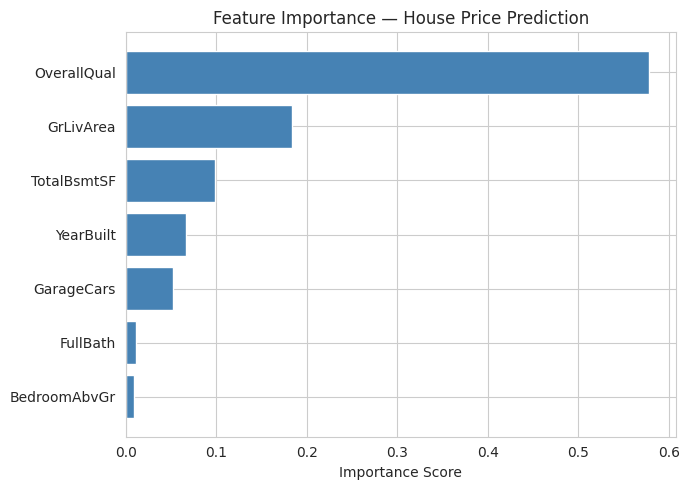

In [9]:
# how much each feature contributed to the model's predictions
importances = model.feature_importances_

# put feature names + their importance scores into a dataframe
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
# sort ascending so the most important feature appears at the top of the chart
feat_df = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(7, 5))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.title('Feature Importance — House Price Prediction')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Summary & Insights

- **Objective:** Predict house sale prices from 7 key property features.
- **Dataset:** Kaggle "House Prices: Advanced Regression Techniques"
  (Ames, Iowa — 1,460 houses), loaded directly from a public URL.
- **Cleaning:** Selected features needed only a simple median fill for
  missing values — these particular columns are well populated in the
  raw data.
- **EDA:** Sale prices are right-skewed — most houses fall between roughly
  $100k–$250k with a long tail of expensive outliers. Living area
  (`GrLivArea`) shows a clear upward trend with price, though not perfectly
  linear — which is why a tree-based model fits better than plain Linear
  Regression.
- **Model:** Gradient Boosting Regressor (200 trees, depth 4).
- **Results:** MAE, RMSE, and R² are printed above — copy your actual run
  numbers into the README.
- **Key finding:** `OverallQual` (quality rating) and `GrLivArea` (living
  area) are consistently the strongest predictors of sale price, matching
  real-world real estate intuition. `YearBuilt` is usually third, reflecting
  a premium for newer construction.